In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import astral
from astral import sun
from pandas.tseries.holiday import USFederalHolidayCalendar, get_calendar

In [2]:
scraped = pd.read_csv('ecocounter_bike_traffic_data.csv')
scraped["Date"] = scraped["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
scraped = scraped.set_index("Date")

# Import and merge direct download count data

In [3]:
bike_direct = pd.read_csv('bike.csv')
bike_direct["DateTime"] = bike_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
bike_direct = bike_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Bike)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Bike)'})
bike_direct["Total (Bike)"] = bike_direct["In (Bike)"] + bike_direct["Out (Bike)"]
bike_direct = bike_direct.set_index("Date")

In [4]:
scooter_direct = pd.read_csv('scooter.csv')
scooter_direct["DateTime"] = scooter_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
scooter_direct = scooter_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Scooter)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Scooter)'})
scooter_direct["Total (Scooter)"] = scooter_direct["In (Scooter)"] + scooter_direct["Out (Scooter)"]
scooter_direct = scooter_direct.set_index("Date")

In [5]:
counts_direct = pd.merge(bike_direct,
                         scooter_direct,
                         how="outer",
                         left_index=True,
                         right_index=True
                        )
counts_direct["In"] = counts_direct["In (Bike)"] + counts_direct["In (Scooter)"]
counts_direct["Out"] = counts_direct["Out (Bike)"] + counts_direct["Out (Scooter)"]
counts_direct["Total"] = counts_direct["Total (Bike)"] + counts_direct["Total (Scooter)"]

Our scraped counts for both bike and scooter match the direct download data, so that's good

In [6]:
pd.merge(scraped, counts_direct, how="left", left_index=True, right_index=True)

,Count,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total
Date,,,,,,,,,,
2024-01-01,307,127,111,238,38,31,69,165,142,307
2024-01-02,360,128,158,286,25,49,74,153,207,360
2024-01-03,475,196,207,403,33,39,72,229,246,475
2024-01-04,580,232,244,476,56,48,104,288,292,580
2024-01-05,646,260,292,552,53,41,94,313,333,646
...,...,...,...,...,...,...,...,...,...,...
2025-12-27,231,66,93,159,31,41,72,97,134,231
2025-12-28,221,69,98,167,23,31,54,92,129,221
2025-12-29,295,88,140,228,26,41,67,114,181,295


### Merging day of week

In [7]:
counts_direct["Day of Week"] = counts_direct.index.day_name()

### Merging days of instruction and days of finals

In [8]:
finalsDates = pd.read_pickle('finalsDates.pkl')
instructionDates = pd.read_pickle('instructionDates.pkl')

# Filter to dates included in the data
finals_mask = (finalsDates <= counts_direct.index.max()) & (finalsDates >= counts_direct.index.min())
instruction_mask = (instructionDates <= counts_direct.index.max()) & (instructionDates >= counts_direct.index.min())
finalsDates = finalsDates[finals_mask]
instructionDates = instructionDates[instruction_mask]

# Make new column for whether a day is within the school year, a finals day, or neither
counts_direct["Academic Day"] = "Non-academic"
counts_direct.loc[finalsDates, "Academic Day"] = "Finals"
counts_direct.loc[instructionDates, "Academic Day"] = "Instruction"

### Merging holidays

Specifically only using holidays on the UC Davis academic calendar

In [9]:
holidayDates = pd.read_pickle('holidayDates.pkl')

# Filter to dates included in the data
holiday_mask = (holidayDates <= counts_direct.index.max()) & (holidayDates >= counts_direct.index.min())
holidayDates = holidayDates[holiday_mask]

# Make a new column for whether a day is a school holiday or not
counts_direct["Holiday"] = [index in holidayDates for index in counts_direct.index]

### Merging hours of daylight

In [10]:
def find_hours_daylight(datetime):
    # Create observer object at Davis bike counter location
    observer = astral.Observer(latitude=38.544406,
                           longitude=-121.74263)
    timedelta = astral.sun.sunrise(observer, datetime) - astral.sun.sunset(observer, datetime)
    seconds = timedelta.total_seconds()
    hours = seconds / 3600
    return hours

hours_of_daylight = []
for index in counts_direct.index:
    hours_of_daylight.append(find_hours_daylight(index))
hours_of_daylight

counts_direct["Hours of daylight"] = hours_of_daylight

### Merging Temperature

In [11]:
temperature = pd.read_csv("temperature.csv")
temperature = temperature[["DATE", "PRCP", "TMAX", "TMIN"]]
temperature = temperature.rename(columns={'DATE': 'Date',
                                          'PRCP': 'Precipitation',
                                          'TMAX': 'Max temperature',
                                          'TMIN': 'Min temperature'
                                         })
temperature["Date"] = temperature["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
temperature = temperature.set_index('Date')

merged_data_direct = pd.merge(counts_direct,
                              temperature,
                              how='inner',
                              left_index=True,
                              right_index=True
                             )

### Resampling dataset to weekly counts

Counts were resampled using summation. Other columns had different aggregation functions:
- Academic Day: used the most common value (mode), e.g. if most days were finals days, that week was considered a finals week
- Holiday: if any day during that week was a holiday, that week was considered a holiday week
- Hours of daylight: used the mean value

In [12]:
counts_direct_weekly = counts_direct.resample("W", label='left').agg(
    In_Bike=('In (Bike)','sum'),
    Out_Bike=('Out (Bike)','sum'),
    Total_Bike=('Total (Bike)','sum'),
    In_Scooter=('In (Scooter)','sum'),
    Out_Scooter=('Out (Scooter)','sum'),
    Total_Scooter=('Total (Scooter)','sum'),
    In=('In','sum'),
    Out=('Out','sum'),
    Total=('Total','sum'),
    Academic_Day=('Academic Day',pd.Series.mode),
    Holiday=('Holiday','any'),
    Hours_of_daylight=('Hours of daylight','mean')
)

counts_direct_weekly = counts_direct_weekly.rename(columns={
    'In_Bike':'In (Bike)',
    'Out_Bike':'Out (Bike)',
    'Total_Bike':'Total (Bike)',
    'In_Scooter':'In (Scooter)',
    'Out_Scooter':'Out (Scooter)',
    'Total_Scooter':'Total (Scooter)',
    'Academic_Day':'Academic Day (Mode)',
    'Holiday':'Holiday (Any)',
    'Hours_of_daylight':'Hours of daylight (Mean)',
})

In [13]:
temperature_weekly = temperature.resample("W", label="left").agg(
    Precipitation_sum=('Precipitation', 'sum'),
    Max_temperature_max=('Max temperature', 'max'),
    Max_temperature_mean=('Max temperature', 'mean'),
    Min_temperature_min=('Min temperature', 'min'),
    Min_temperature_mean=('Min temperature', 'mean')
)
temperature_weekly = temperature_weekly.rename(columns={
    'Precipitation_sum': 'Precipitation (sum)',
    'Max_temperature_max':'Max temperature (max)',
    'Max_temperature_mean':'Max temperature (mean)',
    'Min_temperature_min':'Min temperature (min)',
    'Min_temperature_mean':'Min temperature (mean)'
})

In [14]:
merged_data_direct_weekly = pd.merge(counts_direct_weekly,
                                     temperature_weekly,
                                     how='inner',
                                     left_index=True,
                                     right_index=True
                                    )

### Filter dataset to relevant dates
Filter down to dates in 2024 and 2025 for full years of data--do note that for our weekly data, the date listed is the first day of that week. The first week available is only 1/7/2024, and we could manually add the week of 12/31/2023 if we want? We also have the week of 12/28/2025 even though some of the later days of that week spills over into 2026.

In [15]:
dateMask = (merged_data_direct.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct.index <= datetime.datetime(2025, 12, 31))
dateMask_weekly = (merged_data_direct_weekly.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct_weekly.index <= datetime.datetime(2025, 12, 31))

merged_data_direct = merged_data_direct[dateMask]
merged_data_direct_weekly = merged_data_direct_weekly[dateMask_weekly]

In [16]:
display(merged_data_direct, merged_data_direct_weekly)

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Academic Day,Holiday,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,,,
2024-01-01,127,111,238,38,31,69,165,142,307,Monday,Non-academic,True,14.489649,0.00,60.0,41.0
2024-01-02,128,158,286,25,49,74,153,207,360,Tuesday,Non-academic,False,14.478673,0.00,64.0,44.0
2024-01-03,196,207,403,33,39,72,229,246,475,Wednesday,Non-academic,False,14.466712,0.37,55.0,42.0
2024-01-04,232,244,476,56,48,104,288,292,580,Thursday,Non-academic,False,14.453779,0.01,61.0,36.0
2024-01-05,260,292,552,53,41,94,313,333,646,Friday,Non-academic,False,14.439885,0.00,63.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,66,93,159,31,41,72,97,134,231,Saturday,Non-academic,False,14.526470,0.09,60.0,38.0
2025-12-28,69,98,167,23,31,54,92,129,221,Sunday,Non-academic,False,14.520021,0.00,54.0,38.0
2025-12-29,88,140,228,26,41,67,114,181,295,Monday,Non-academic,False,14.512548,0.00,56.0,34.0


,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Academic Day (Mode),Holiday (Any),Hours of daylight (Mean),Precipitation (sum),Max temperature (max),Max temperature (mean),Min temperature (min),Min temperature (mean)
Date,,,,,,,,,,,,,,,,,
2024-01-07,6139,5582,11721,1024,788,1812,7163,6370,13533,Instruction,False,14.335397,0.24,60.0,57.285714,36.0,38.571429
2024-01-14,4995,4667,9662,914,717,1631,5909,5384,11293,Instruction,True,14.177091,1.04,66.0,61.857143,38.0,41.285714
2024-01-21,5900,5502,11402,1061,832,1893,6961,6334,13295,Instruction,False,13.983069,1.13,69.0,64.000000,33.0,45.714286
2024-01-28,5365,4961,10326,1016,803,1819,6381,5764,12145,Instruction,False,13.759835,2.69,73.0,66.142857,43.0,46.714286
2024-02-04,5342,5036,10378,986,715,1701,6328,5751,12079,Instruction,False,13.513649,1.46,65.0,61.428571,30.0,37.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,4497,4605,9102,1797,1424,3221,6294,6029,12323,Instruction,False,14.389602,0.00,58.0,50.833333,37.0,40.166667
2025-12-07,2888,2981,5869,1147,976,2123,4035,3957,7992,Finals,False,14.486671,0.02,47.0,45.857143,39.0,41.000000
2025-12-14,951,997,1948,337,362,699,1288,1359,2647,Non-academic,False,14.535702,0.28,68.0,55.000000,39.0,45.571429


# Visualization

<Axes: xlabel='Date'>

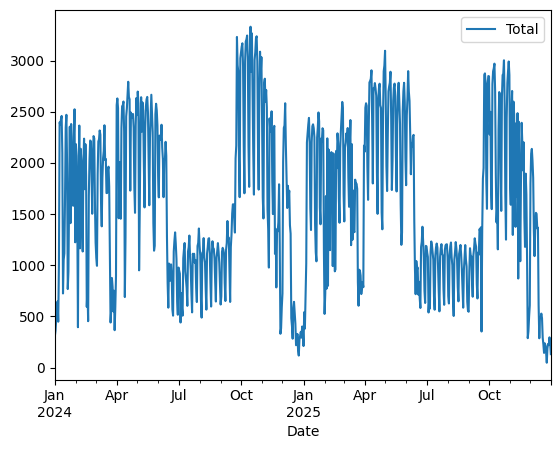

In [17]:
merged_data_direct[[
    # "In",
    # "Out",
    "Total"
]].plot()

<Axes: xlabel='Date'>

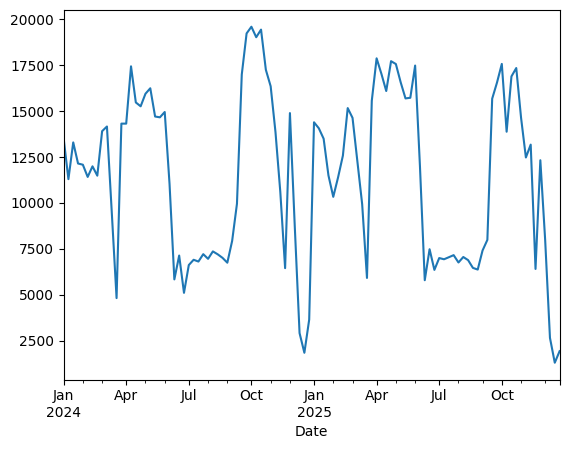

In [18]:
merged_data_direct_weekly["Total"].plot()

# Analysis

Assumptions
- Poisson Response: The response variable is a count per unit of time or space, described by a Poisson distribution.
- Independence: The observations must be independent of one another.
- Mean=Variance: By definition, the mean of a Poisson random variable must be equal to its variance.
- Linearity The log of the mean rate, log(λ), must be a linear function of x.

- https://bookdown.org/roback/bookdown-BeyondMLR/ch-poissonreg.html
- https://www.statsmodels.org/dev/generated/statsmodels.stats.stattools.durbin_watson.html
- https://stackoverflow.com/questions/28951982/using-weightings-in-a-poisson-model-using-statsmodels-module
- https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.NegativeBinomial.html
- https://timeseriesreasoning.com/contents/negative-binomial-regression-model/
- https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/

In [19]:
#%pip install statsmodels
#merged_data_direct.head()
merged_data_direct

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Academic Day,Holiday,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,,,
2024-01-01,127,111,238,38,31,69,165,142,307,Monday,Non-academic,True,14.489649,0.00,60.0,41.0
2024-01-02,128,158,286,25,49,74,153,207,360,Tuesday,Non-academic,False,14.478673,0.00,64.0,44.0
2024-01-03,196,207,403,33,39,72,229,246,475,Wednesday,Non-academic,False,14.466712,0.37,55.0,42.0
2024-01-04,232,244,476,56,48,104,288,292,580,Thursday,Non-academic,False,14.453779,0.01,61.0,36.0
2024-01-05,260,292,552,53,41,94,313,333,646,Friday,Non-academic,False,14.439885,0.00,63.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,66,93,159,31,41,72,97,134,231,Saturday,Non-academic,False,14.526470,0.09,60.0,38.0
2025-12-28,69,98,167,23,31,54,92,129,221,Sunday,Non-academic,False,14.520021,0.00,54.0,38.0
2025-12-29,88,140,228,26,41,67,114,181,295,Monday,Non-academic,False,14.512548,0.00,56.0,34.0


In [20]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

## Poisson

In [21]:
merged_data_direct = merged_data_direct.reset_index()
poisson_model = smf.glm("Total ~ Q('Day of Week') + Q('Max temperature') + Q('Min temperature') + Q('Precipitation')", merged_data_direct, family=sm.families.Poisson())
results = poisson_model.fit(cov_type='HC0')
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Total   No. Observations:                  723
Model:                            GLM   Df Residuals:                      713
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2687e+05
Date:                Mon, 09 Mar 2026   Deviance:                   2.4718e+05
Time:                        18:00:47   Pearson chi2:                 2.26e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC0                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         7.7144      0.099     77.595      0.000       7.519       7.909
Q('Day of Week')[T.Monday]       -0.0144      0.061     -0.236      0.813      -0.134       0.105
Q('Day of Week')[T.Saturday]     -0.3182      0.063     -5.029      0.000      -0.442      -0.194
Q('Day of Week')[T.Sunday]       -0.4646      0.061     -7.657      0.000      -0.584      -0.346
Q('Day of Week')[T.Thursday]      0.0651      0.064      1.025      0.305      -0.059       0.190
Q('Day of Week')[T.Tuesday]       0.0714      0.058      1.230      0.219      -0.042       0.185
Q('Day of Week')[T.Wednesday]     0.0714      0.060      1.182      0.237      -0.047       0.190
Q('Max temperature')              0.0063      0.002      2.928      0.003       0.002       0.010
Q('Min temperature')             -0.0145      0.003     -4.497      0.000      -0.021      -0.008
Q('Precipitation')               -0.4711      0.142     -3.323      0.001      -0.749      -0.193
=================================================================================================
"""

In [ ]:
#Assumption #1: Independence (use Durbin-Watson)
durbin_watson(results.resid_deviance, axis=0)

# Assumption #2: Mean=Variance (Equidispersion)
mean_count = merged_data_direct["Total"].mean()
variance_count = merged_data_direct["Total"].var()
print(f"Mean: {mean_count}, Variance: {variance_count}")


Mean: 1625.749658002736, Variance: 629296.8564211158


The equidispersion assumption for the Poisson model was violated, so we must refocus on robust forms of Poisson or other models.

## Negative Binomial

In [34]:
negative_binomial_model = smf.negativebinomial("Total ~ Q('Day of Week') + Q('Max temperature') + Q('Min temperature') + Q('Precipitation') + Q('Holiday') + Q('Academic Day') + Q('Hours of daylight')", merged_data_direct)
neg_bi_results = negative_binomial_model.fit()
neg_bi_results.summary()

Optimization terminated successfully.
         Current function value: 7.445726
         Iterations: 28
         Function evaluations: 41
         Gradient evaluations: 41


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:                  Total   No. Observations:                  723
Model:               NegativeBinomial   Df Residuals:                      709
Method:                           MLE   Df Model:                           13
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                 0.08247
Time:                        19:57:33   Log-Likelihood:                -5383.3
converged:                       True   LL-Null:                       -5867.1
Covariance Type:            nonrobust   LLR p-value:                1.463e-198
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             7.1781      0.192     37.456      0.000       6.802       7.554
Q('Day of Week')[T.Monday]            0.0303      0.041      0.739      0.460      -0.050       0.110
Q('Day of Week')[T.Saturday]         -0.2672      0.041     -6.491      0.000      -0.348      -0.186
Q('Day of Week')[T.Sunday]           -0.3957      0.041     -9.552      0.000      -0.477      -0.314
Q('Day of Week')[T.Thursday]          0.0416      0.041      1.012      0.311      -0.039       0.122
Q('Day of Week')[T.Tuesday]           0.0578      0.041      1.417      0.156      -0.022       0.138
Q('Day of Week')[T.Wednesday]         0.0439      0.041      1.079      0.280      -0.036       0.124
Q('Holiday')[T.True]                 -0.9124      0.059    -15.559      0.000      -1.027      -0.797
Q('Academic Day')[T.Instruction]      0.2225      0.053      4.195      0.000       0.119       0.326
Q('Academic Day')[T.Non-academic]    -0.6968      0.055    -12.742      0.000      -0.804      -0.590
Q('Max temperature')                  0.0111      0.001      7.717      0.000       0.008       0.014
Q('Min temperature')                 -0.0066      0.002     -3.077      0.002      -0.011      -0.002
Q('Precipitation')                   -0.3693      0.054     -6.780      0.000      -0.476      -0.263
Q('Hours of daylight')               -0.0158      0.009     -1.681      0.093      -0.034       0.003
alpha                                 0.0856      0.005     18.944      0.000       0.077       0.094
=====================================================================================================
"""

We note that alpha is 0, and so we have overdispersion. Violation of equidispersion, Poisson should not be used.

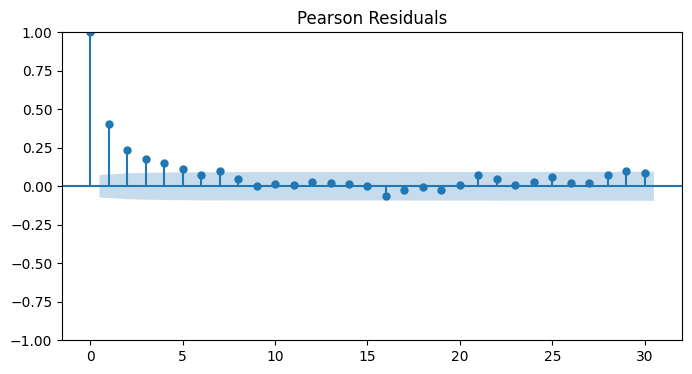

Optimization terminated successfully.
         Current function value: 7.445726
         Iterations: 28
         Function evaluations: 41
         Gradient evaluations: 41
                     NegativeBinomial Regression Results                      
Dep. Variable:                  Total   No. Observations:                  723
Model:               NegativeBinomial   Df Residuals:                      709
Method:                           MLE   Df Model:                           13
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                 0.08247
Time:                        20:23:33   Log-Likelihood:                -5383.3
converged:                       True   LL-Null:                       -5867.1
Covariance Type:            nonrobust   LLR p-value:                1.463e-198
                                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

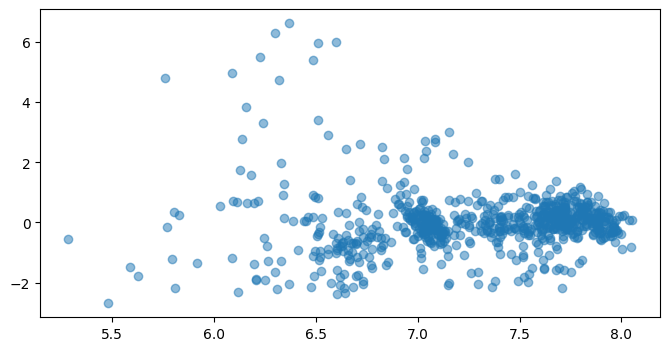

In [36]:
neg_bi_residuals = neg_bi_results.resid_pearson
neg_bi_residuals

#Assumption #1: Independence (use Durbin-Watson)
durbin_watson(neg_bi_residuals, axis=0)
## Also check for autocorrelation
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(neg_bi_residuals, lags=30, ax=ax)
plt.title("Pearson Residuals")
plt.show()

#Assumption #2: Linearity of Log-Link

# We plot the predicted counts against the residuals. 
# We want to see a random cloud of static
neg_bi_results = negative_binomial_model.fit() 
fitted_values = neg_bi_results.fittedvalues

plt.figure(figsize=(8, 4))
plt.scatter(fitted_values, neg_bi_residuals, alpha=0.5)

# (Weak) Assumption #3: Overdispersion
print(neg_bi_results.summary())

In [35]:
subset_merged = merged_data_direct[["Total", "Max temperature", "Min temperature", "Precipitation", "Day of Week", "Holiday", "Academic Day", "Hours of daylight"]]
corr_merged = pd.get_dummies(subset_merged)
correlation_matrix = corr_merged.corr()

correlation_matrix

,Total,Max temperature,Min temperature,Precipitation,Holiday,Hours of daylight,Day of Week_Friday,Day of Week_Monday,Day of Week_Saturday,Day of Week_Sunday,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday,Academic Day_Finals,Academic Day_Instruction,Academic Day_Non-academic
Total,1.000000,0.021551,-0.078941,-0.154828,-0.261030,0.013361,0.064352,0.031152,-0.187371,-0.282968,0.121033,0.125842,0.126826,0.053628,0.685406,-0.720951
Max temperature,0.021551,1.000000,0.831990,-0.297791,-0.096064,-0.776645,-0.000142,-0.017845,0.002131,-0.015408,0.006732,0.006251,0.018175,-0.047303,-0.338542,0.365258
Min temperature,-0.078941,0.831990,1.000000,-0.229837,-0.067652,-0.690314,-0.013732,0.009296,-0.004476,0.016462,-0.016958,-0.012499,0.021730,-0.023016,-0.376677,0.393515
Precipitation,-0.154828,-0.297791,-0.229837,1.000000,0.066853,0.268587,-0.020097,0.013069,-0.001019,0.007158,0.040725,-0.001668,-0.037734,-0.032449,0.060447,-0.047464
Holiday,-0.261030,-0.096064,-0.067652,0.066853,1.000000,0.097108,0.020739,0.121491,-0.081280,-0.081280,0.020739,-0.020767,0.019878,-0.044078,-0.056628,0.076728
Hours of daylight,0.013361,-0.776645,-0.690314,0.268587,0.097108,1.000000,-0.002427,0.003232,-0.002420,-0.002411,-0.002434,0.003219,0.003204,-0.031916,0.318122,-0.310027
Day of Week_Friday,0.064352,-0.000142,-0.013732,-0.020097,0.020739,-0.002427,1.000000,-0.166798,-0.165869,-0.165869,-0.165869,-0.166798,-0.166798,0.021623,0.006448,-0.015924
Day of Week_Monday,0.031152,-0.017845,0.009296,0.013069,0.121491,0.003232,-0.166798,1.000000,-0.166798,-0.166798,-0.166798,-0.167732,-0.167732,0.020675,0.001939,-0.010925
Day of Week_Saturday,-0.187371,0.002131,-0.004476,-0.001019,-0.081280,-0.002420,-0.165869,-0.166798,1.000000,-0.165869,-0.165869,-0.166798,-0.166798,-0.052760,-0.025184,0.048477
Day of Week_Sunday,-0.282968,-0.015408,0.016462,0.007158,-0.081280,-0.002411,-0.165869,-0.166798,-0.165869,1.000000,-0.165869,-0.166798,-0.166798,-0.052760,-0.025184,0.048477
